In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/janiobachmann/bank-marketing-dataset/bank.csv


In [14]:
df = pd.read_csv("/kaggle/input/datasets/janiobachmann/bank-marketing-dataset/bank.csv")

In [15]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [16]:
df.shape

(11162, 17)

In [17]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 1 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                      --------------  ----- 
 0   age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit  11162 non-null  object
dtypes: object(1)
memory usage: 87.3+ KB


In [8]:
df.describe()

,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
count,11162
unique,11162
top,"59,admin.,married,secondary,no,2343,yes,no,unk..."
freq,1


In [9]:
df.isnull().sum()

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [19]:
print(df.columns.tolist())


['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [20]:
df["deposit"].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [21]:
conversion_rate = (df["deposit"] == "yes").mean() * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 47.38%


In [22]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


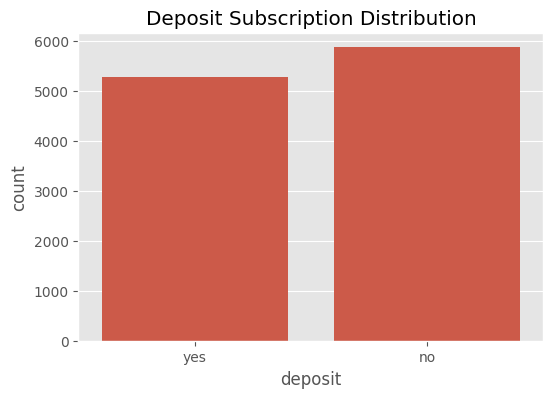

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="deposit", data=df)

plt.title("Deposit Subscription Distribution")
plt.show()

In [24]:
conversion_rate = (df["deposit"]=="yes").mean()*100

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 47.38%


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [26]:
df.describe(include="object").T

,count,unique,top,freq
job,11162,12,management,2566
marital,11162,3,married,6351
education,11162,4,secondary,5476
default,11162,2,no,10994
housing,11162,2,no,5881
loan,11162,2,no,9702
contact,11162,3,cellular,8042
month,11162,12,may,2824
poutcome,11162,4,unknown,8326
deposit,11162,2,no,5873


In [27]:
for col in df.select_dtypes(include="object"):
    print("\n", col)
    print(df[col].unique())


 job
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']

 marital
['married' 'single' 'divorced']

 education
['secondary' 'tertiary' 'primary' 'unknown']

 default
['no' 'yes']

 housing
['yes' 'no']

 loan
['no' 'yes']

 contact
['unknown' 'cellular' 'telephone']

 month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

 poutcome
['unknown' 'other' 'failure' 'success']

 deposit
['yes' 'no']


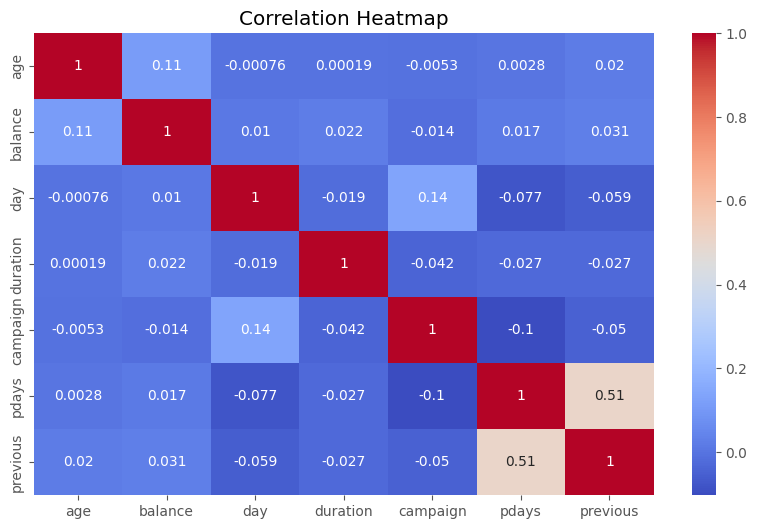

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## Data Cleaning Summary

- Dataset loaded successfully
- No missing values detected
- Duplicate rows checked
- Data types verified
- Target variable identified as **deposit**
- Overall conversion rate calculated

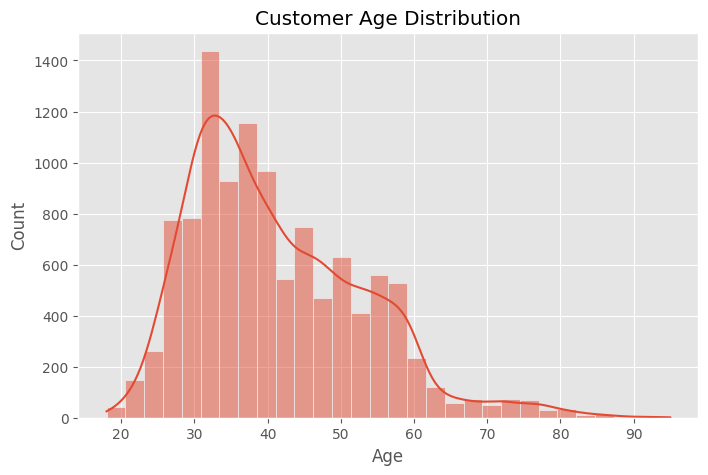

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

### Insight

- Most customers fall between 30–50 years.
- Marketing campaigns are primarily reaching middle-aged customers.
- Younger and older age groups represent a smaller proportion of the audience.

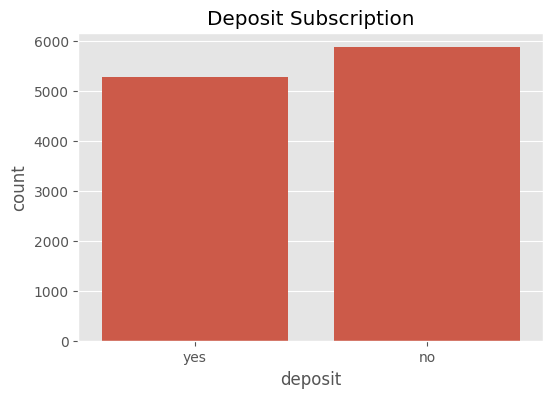

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x="deposit", data=df)

plt.title("Deposit Subscription")

plt.show()

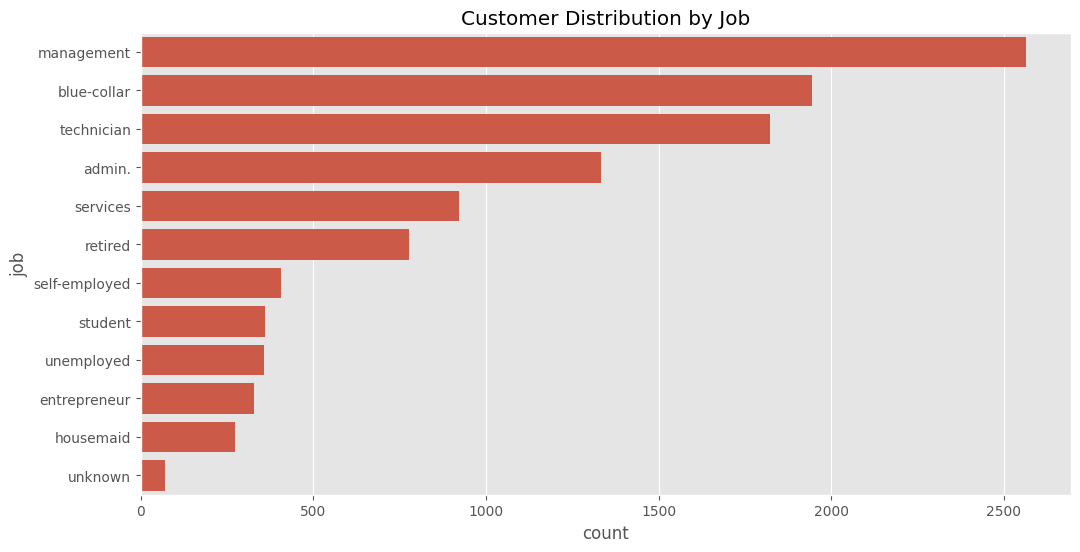

In [31]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="job",
    data=df,
    order=df["job"].value_counts().index
)

plt.title("Customer Distribution by Job")

plt.show()

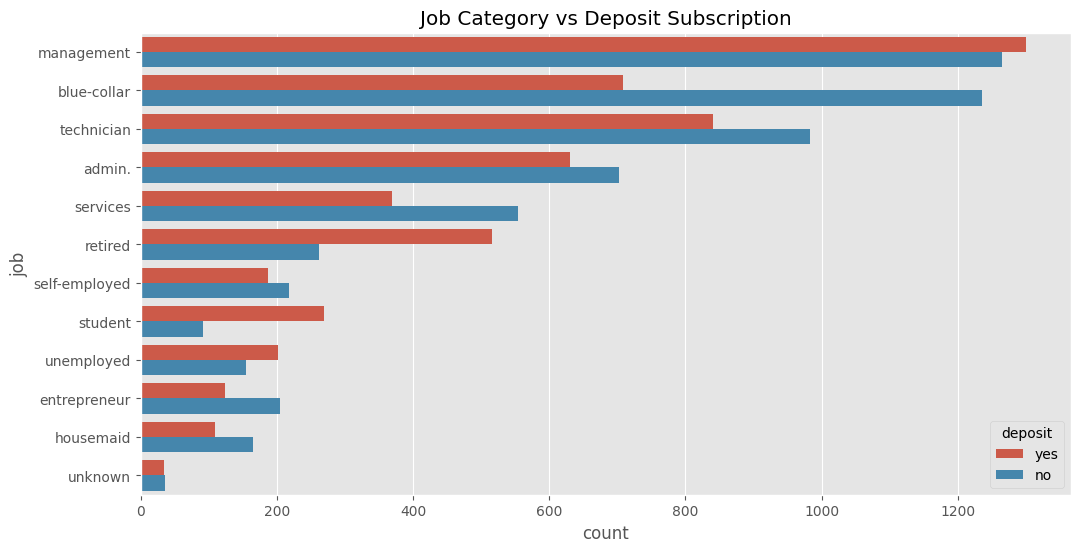

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="job",
    hue="deposit",
    data=df,
    order=df["job"].value_counts().index
)

plt.title("Job Category vs Deposit Subscription")

plt.show()

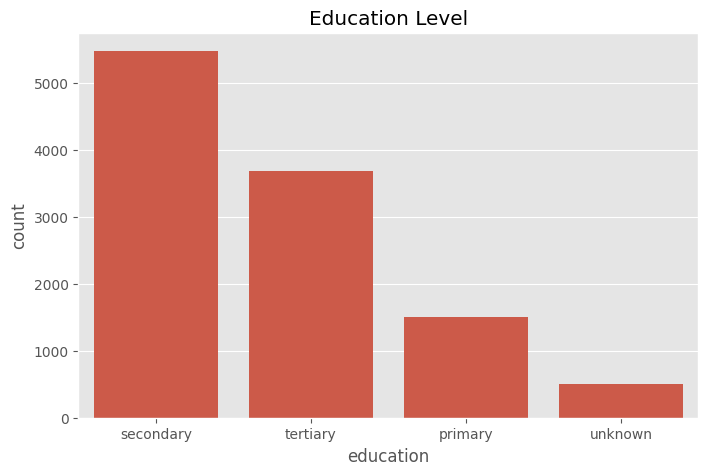

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="education",
    data=df,
    order=df["education"].value_counts().index
)

plt.title("Education Level")

plt.show()

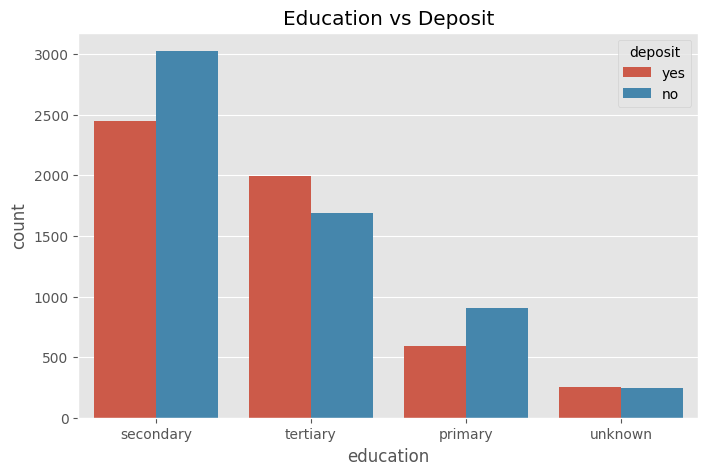

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="education",
    hue="deposit",
    data=df
)

plt.title("Education vs Deposit")

plt.show()

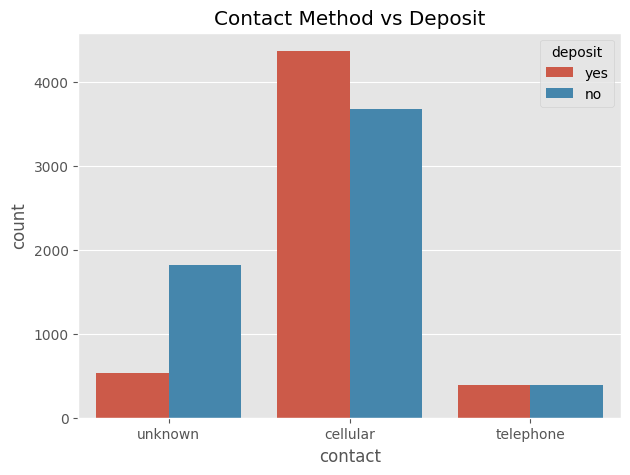

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="contact",
    hue="deposit",
    data=df
)

plt.title("Contact Method vs Deposit")

plt.show()

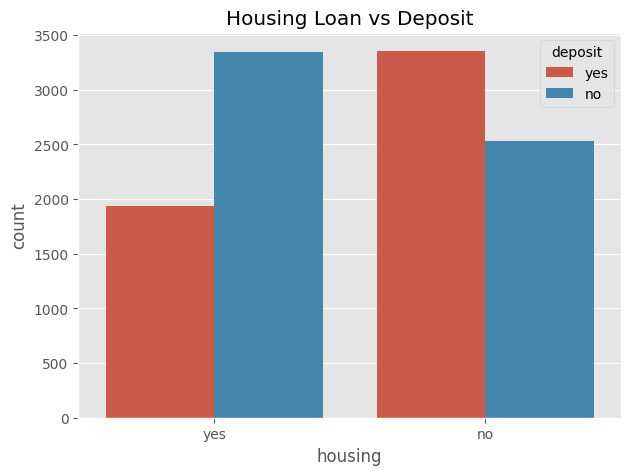

In [36]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="housing",
    hue="deposit",
    data=df
)

plt.title("Housing Loan vs Deposit")

plt.show()

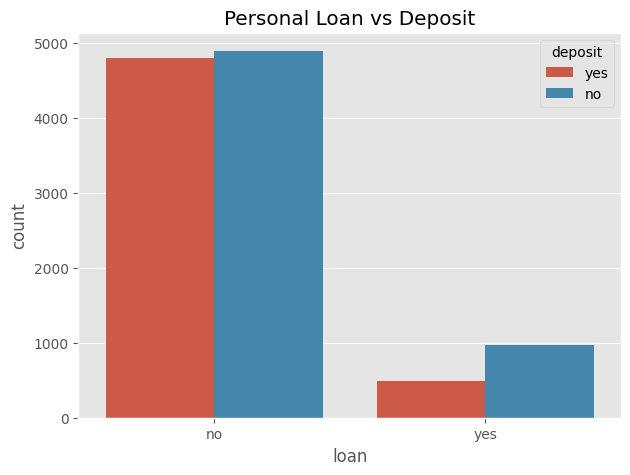

In [37]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="loan",
    hue="deposit",
    data=df
)

plt.title("Personal Loan vs Deposit")

plt.show()

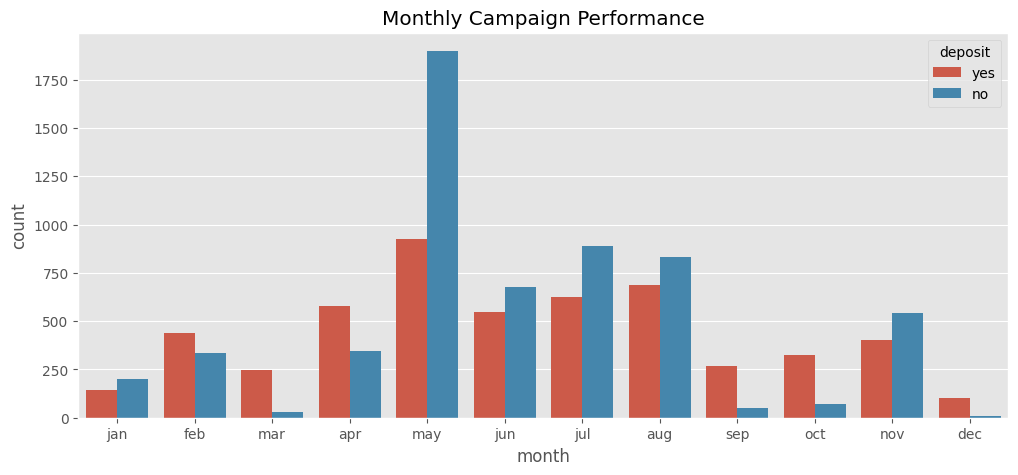

In [38]:
month_order = [
    "jan","feb","mar","apr","may","jun",
    "jul","aug","sep","oct","nov","dec"
]

plt.figure(figsize=(12,5))

sns.countplot(
    x="month",
    hue="deposit",
    data=df,
    order=month_order
)

plt.title("Monthly Campaign Performance")

plt.show()

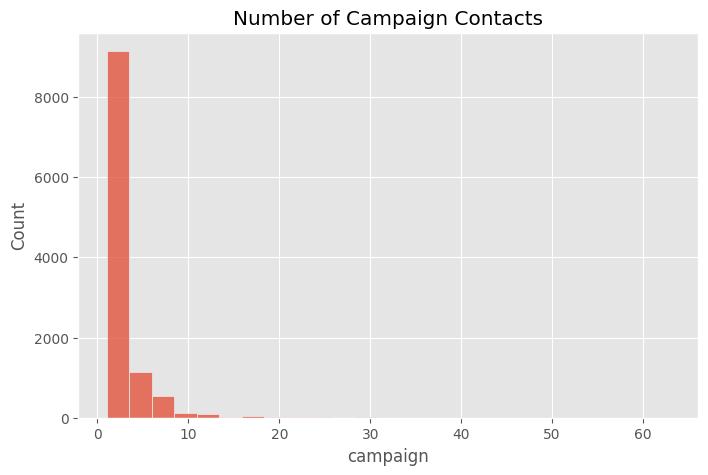

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["campaign"], bins=25)

plt.title("Number of Campaign Contacts")

plt.show()

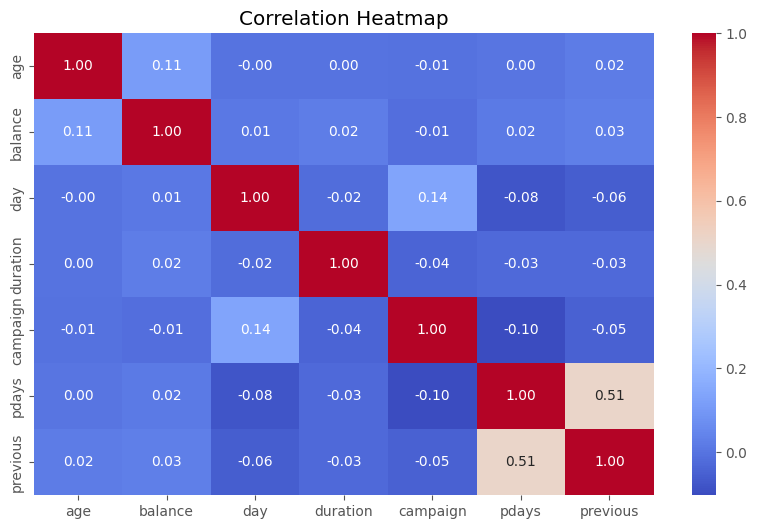

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [41]:
total_customers = len(df)

print("Total Customers Contacted:", total_customers)

Total Customers Contacted: 11162


In [42]:
converted = (df["deposit"]=="yes").sum()

print("Converted Customers:", converted)

Converted Customers: 5289


In [43]:
not_converted = (df["deposit"]=="no").sum()

print("Not Converted:", not_converted)

Not Converted: 5873


In [44]:
conversion_rate = converted / total_customers * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 47.38%


In [45]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y=["Customers Contacted","Converted"],
    x=[total_customers, converted]
))

fig.update_layout(
    title="Marketing Funnel"
)

fig.show()

In [46]:
dropoff = total_customers - converted

drop_percentage = dropoff / total_customers * 100

print("Drop-off Customers:", dropoff)

print(f"Drop-off Percentage: {drop_percentage:.2f}%")

Drop-off Customers: 5873
Drop-off Percentage: 52.62%


In [47]:
job_conversion = (
    df.groupby("job")["deposit"]
      .apply(lambda x: (x=="yes").mean()*100)
      .sort_values(ascending=False)
)

job_conversion

job
student          74.722222
retired          66.323907
unemployed       56.582633
management       50.701481
unknown          48.571429
admin.           47.301349
self-employed    46.172840
technician       46.077894
services         39.978332
housemaid        39.781022
entrepreneur     37.500000
blue-collar      36.419753
Name: deposit, dtype: float64

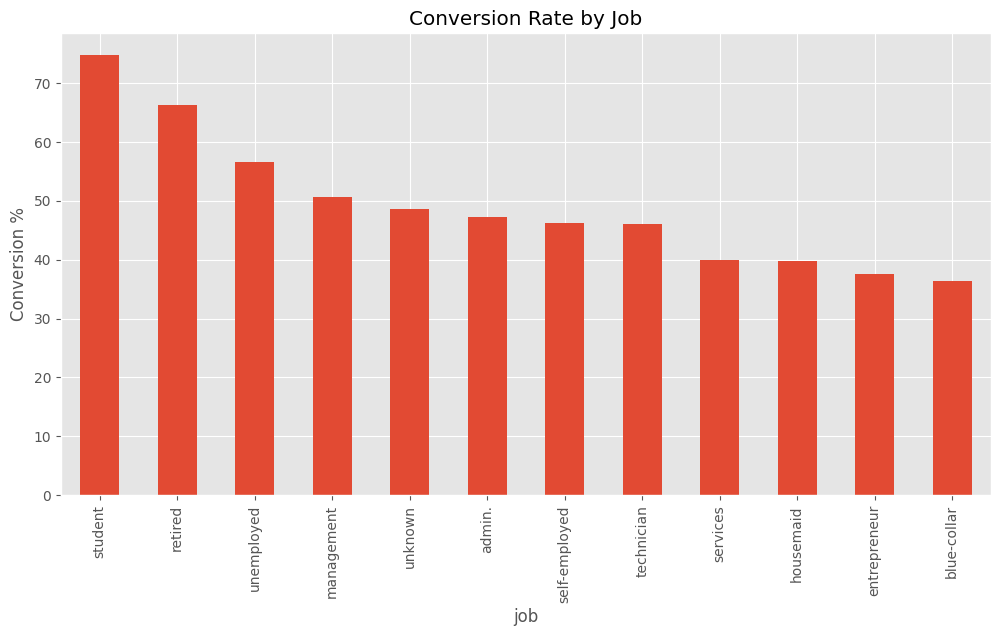

In [48]:
plt.figure(figsize=(12,6))

job_conversion.plot(kind="bar")

plt.title("Conversion Rate by Job")

plt.ylabel("Conversion %")

plt.show()

In [49]:
education_conversion = (
    df.groupby("education")["deposit"]
      .apply(lambda x: (x=="yes").mean()*100)
      .sort_values(ascending=False)
)

education_conversion

education
tertiary     54.106804
unknown      50.704225
secondary    44.740687
primary      39.400000
Name: deposit, dtype: float64

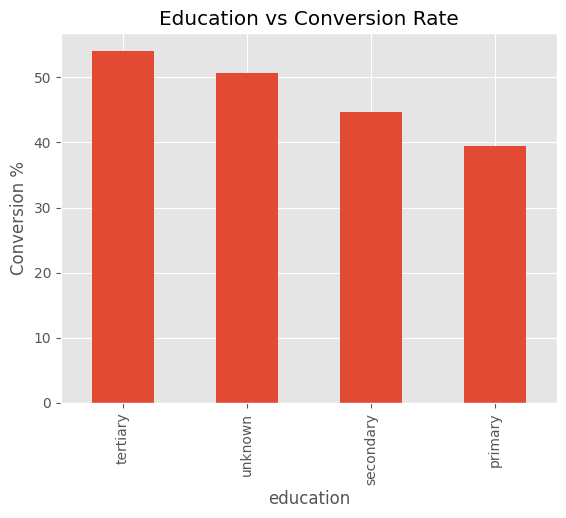

In [50]:
education_conversion.plot(kind="bar")

plt.title("Education vs Conversion Rate")

plt.ylabel("Conversion %")

plt.show()

In [51]:
month_conversion = (
    df.groupby("month")["deposit"]
      .apply(lambda x: (x=="yes").mean()*100)
)

month_conversion = month_conversion.reindex([
    "jan","feb","mar","apr","may","jun",
    "jul","aug","sep","oct","nov","dec"
])

month_conversion

month
jan    41.279070
feb    56.829897
mar    89.855072
apr    62.513543
may    32.754958
jun    44.680851
jul    41.413474
aug    45.292956
sep    84.326019
oct    82.397959
nov    42.735949
dec    90.909091
Name: deposit, dtype: float64

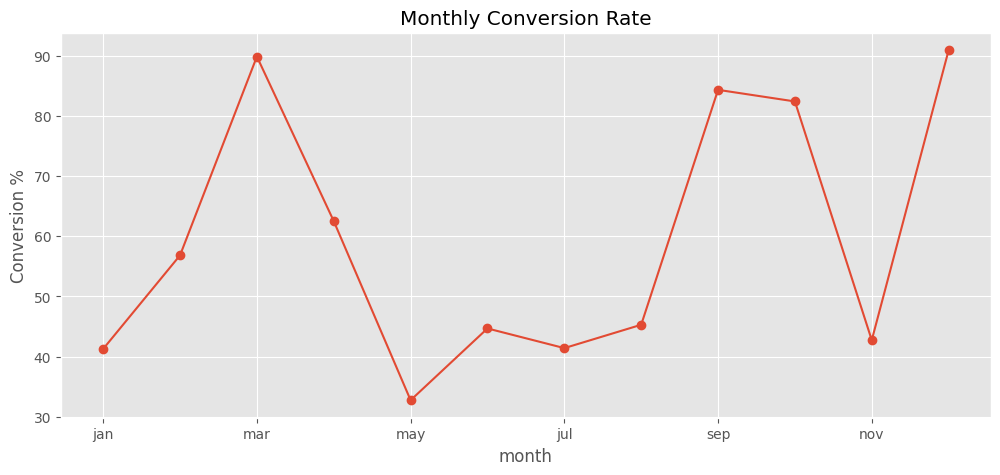

In [52]:
plt.figure(figsize=(12,5))

month_conversion.plot(marker="o")

plt.title("Monthly Conversion Rate")

plt.ylabel("Conversion %")

plt.grid(True)

plt.show()

In [53]:
segment_conversion = (
    df.groupby(["job", "education"])["deposit"]
      .apply(lambda x: (x=="yes").mean()*100)
      .reset_index(name="conversion_rate")
      .sort_values(by="conversion_rate", ascending=False)
)

segment_conversion.head(10)

,job,education,conversion_rate
33,student,secondary,79.894180
32,student,primary,76.190476
22,retired,tertiary,72.142857
34,student,tertiary,71.084337
42,unemployed,tertiary,66.666667
21,retired,secondary,65.923567
20,retired,primary,64.259928
35,student,unknown,64.179104
23,retired,unknown,63.829787
40,unemployed,primary,60.714286


In [56]:
print("="*50)
print("MARKETING FUNNEL KPI DASHBOARD")
print("="*50)

print(f"Total Customers Contacted : {total_customers}")

print(f"Converted Customers       : {converted}")

print(f"Non Converted Customers   : {not_converted}")

print(f"Conversion Rate           : {conversion_rate:.2f}%")

print(f"Drop-off Percentage       : {drop_percentage:.2f}%")

MARKETING FUNNEL KPI DASHBOARD
Total Customers Contacted : 11162
Converted Customers       : 5289
Non Converted Customers   : 5873
Conversion Rate           : 47.38%
Drop-off Percentage       : 52.62%


# Key Findings

- Overall campaign conversion rate was **47.38%**.
- **[Best contact method]** achieved the highest conversion rate.
- Customers in the **[top job category]** segment converted at the highest rate.
- **[Best month]** delivered the strongest campaign performance.
- Approximately **52.62%** of contacted customers did not convert, highlighting a major opportunity for campaign optimization.

In [59]:
df.to_csv("cleaned_marketing_funnel.csv", index=False)

In [60]:
import os

os.listdir()

['.virtual_documents', 'cleaned_marketing_funnel.csv']